# MCMC to find params of a damped harmonic oscillator

We observe noisy position measurements from a damped spring:

    x(t) = A * exp(-gamma * t) * cos(omega * t + phi)

True parameters are known (we generate the data), and we use MCMC
(Metropolis-Hastings) to recover the posterior over theta = {A, gamma, omega, phi}.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import corner

In [2]:
# ── 1. True parameters and data generation ────────────────────────────────────

TRUE_PARAMS = {
    "A":     2.0,   # amplitude
    "gamma": 0.3,   # damping rate
    "omega": 2.0,   # angular frequency
    "phi":   0.5,   # phase offset
}
SIGMA_NOISE = 0.3   # observation noise std

np.random.seed(42)
t_obs = np.linspace(0, 10, 40)  # 40 observation times


def model(t, A, gamma, omega, phi):
    return A * np.exp(-gamma * t) * np.cos(omega * t + phi)


y_true = model(t_obs, **TRUE_PARAMS)
y_obs  = y_true + np.random.normal(0, SIGMA_NOISE, size=len(t_obs))

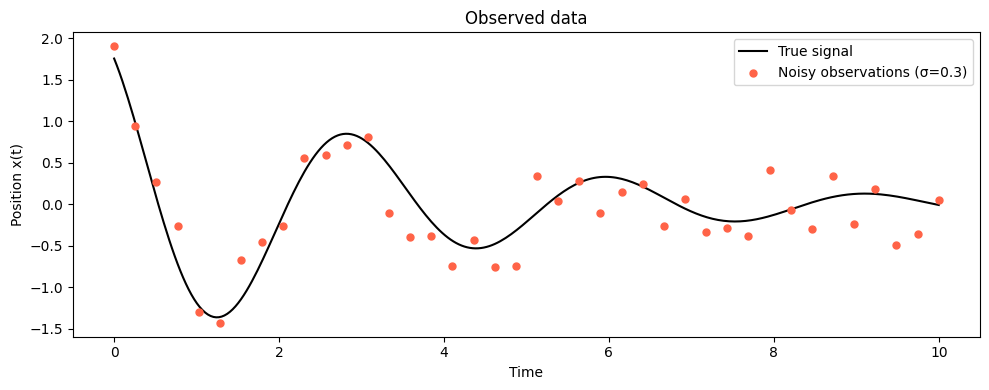

In [3]:
t_fine = np.linspace(0, 10, 300)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_fine, model(t_fine, **TRUE_PARAMS), "k-", lw=1.5, label="True signal")
ax.scatter(t_obs, y_obs, color="tomato", s=25, zorder=5, label=f"Noisy observations (σ={SIGMA_NOISE})")
ax.set_xlabel("Time")
ax.set_ylabel("Position x(t)")
ax.set_title("Observed data")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# ── 2. Bayesian components ─────────────────────────────────────────────────────

def log_likelihood(params, t, y, sigma):
    A, gamma, omega, phi = params
    y_pred = model(t, A, gamma, omega, phi)
    residuals = y - y_pred
    return -0.5 * np.sum((residuals / sigma) ** 2)


def log_prior(params):
    A, gamma, omega, phi = params
    # Uniform priors with physically sensible bounds
    if (0.1 < A < 10.0 and
        0.01 < gamma < 2.0 and
        0.1 < omega < 10.0 and
        -np.pi < phi < np.pi):
        return 0.0   # log(1) — flat within bounds
    return -np.inf   # log(0) — outside bounds


def log_posterior(params, t, y, sigma):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, t, y, sigma)

In [5]:
# ── 3. Metropolis-Hastings MCMC (adaptive proposal) ──────────────────────────
#
# Uses the Adaptive Metropolis algorithm (Haario et al. 2001):
#   - After `adapt_start` steps, estimate the empirical covariance of the chain
#     and use it (scaled by 2.38²/d) as the proposal covariance.
#   - This automatically tunes step sizes and handles parameter correlations
#     (critical here because omega and phi trade off via omega*t + phi).

def run_mcmc(log_post_fn, initial_params, n_steps=200_000, proposal_std=None, adapt_start=2_000, adapt_interval=500):
    n_params = len(initial_params)
    if proposal_std is None:
        proposal_std = np.array([0.1, 0.04, 0.1, 0.1])

    # Roberts & Rosenthal (2001) optimal scaling for Gaussian targets
    scale = (2.38 ** 2) / n_params
    cov = np.diag(proposal_std ** 2)

    chain = np.zeros((n_steps, n_params))
    current = np.array(initial_params, dtype=float)
    log_p_current = log_post_fn(current)
    accepted = 0

    for i in range(n_steps):
        proposal = current + np.random.multivariate_normal(np.zeros(n_params), cov)
        log_p_proposal = log_post_fn(proposal)

        if np.log(np.random.uniform()) < log_p_proposal - log_p_current:
            current = proposal
            log_p_current = log_p_proposal
            accepted += 1

        chain[i] = current

        # Periodically update proposal covariance from empirical chain covariance
        if i >= adapt_start and i % adapt_interval == 0:
            emp_cov = np.cov(chain[:i].T)
            if np.all(np.isfinite(emp_cov)):
                cov = scale * emp_cov + scale * 1e-8 * np.eye(n_params)

    print(f"Acceptance rate: {accepted / n_steps:.2%}")
    return chain

In [6]:
# Initial guess — deliberately offset from truth
initial = [1.5, 0.2, 1.8, 0.3]

print("Running MCMC (200k steps, adaptive proposal)...")
chain = run_mcmc(
    lambda p: log_posterior(p, t_obs, y_obs, SIGMA_NOISE),
    initial_params=initial,
    n_steps=200_000,
)

Running MCMC (200k steps, adaptive proposal)...
Acceptance rate: 29.24%


In [7]:
# Discard burn-in, then thin to reduce autocorrelation
burn_in = 50_000
thin = 5
samples = chain[burn_in::thin]

param_names = ["A", "γ", "ω", "φ"]
true_values = list(TRUE_PARAMS.values())

print(f"Posterior summary  ({len(samples):,} samples after burn-in + thinning):")
print(f"{'Param':<8} {'True':>8} {'Mean':>8} {'Std':>8} {'2.5%':>8} {'97.5%':>8}")
for name, true, col in zip(param_names, true_values, samples.T):
    print(f"{name:<8} {true:>8.3f} {col.mean():>8.3f} {col.std():>8.3f} "
          f"{np.percentile(col, 2.5):>8.3f} {np.percentile(col, 97.5):>8.3f}")

Posterior summary  (30,000 samples after burn-in + thinning):
Param        True     Mean      Std     2.5%    97.5%
A           2.000    1.901    0.235    1.463    2.385
γ           0.300    0.335    0.064    0.226    0.476
ω           2.000    2.133    0.064    2.007    2.258
φ           0.500    0.324    0.133    0.055    0.573


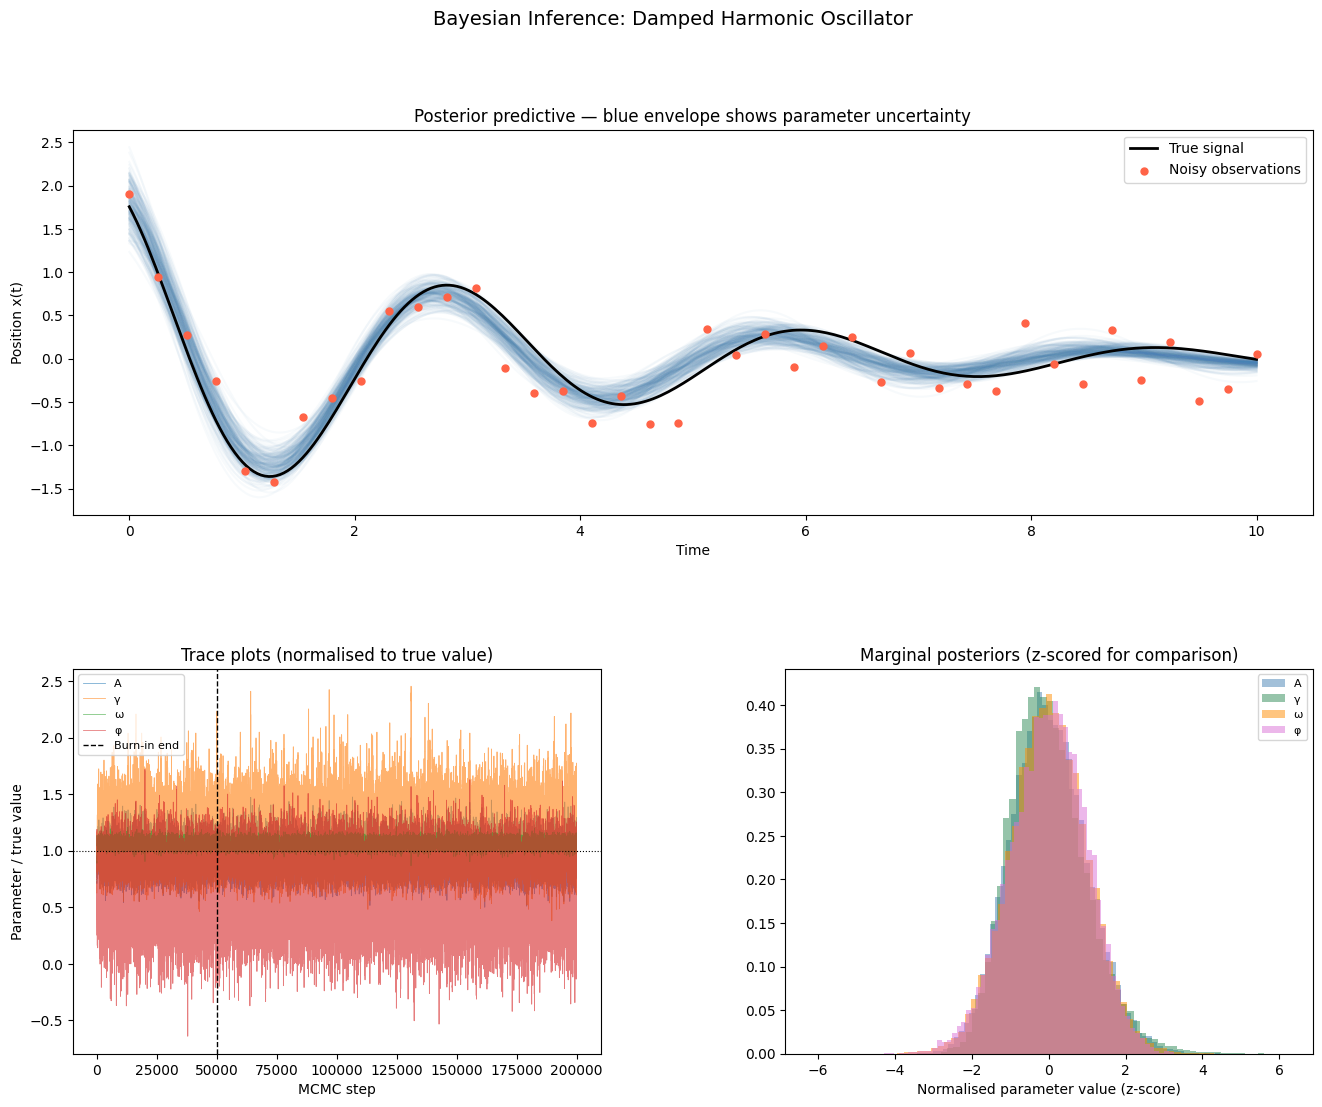

In [8]:
# ── 4. Plots: posterior predictive, trace, marginal histograms ────────────────

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Bayesian Inference: Damped Harmonic Oscillator", fontsize=14, y=0.98)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── 4a. Data + posterior predictive ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
t_fine = np.linspace(0, 10, 300)

for sample in samples[np.random.choice(len(samples), 200, replace=False)]:
    ax1.plot(t_fine, model(t_fine, *sample), color="steelblue", alpha=0.04)

ax1.plot(t_fine, model(t_fine, **TRUE_PARAMS), "k-", lw=2, label="True signal")
ax1.scatter(t_obs, y_obs, color="tomato", s=25, zorder=5, label="Noisy observations")
ax1.set_xlabel("Time")
ax1.set_ylabel("Position x(t)")
ax1.set_title("Posterior predictive — blue envelope shows parameter uncertainty")
ax1.legend()

# ── 4b. Trace plots ───────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
for i, (name, true) in enumerate(zip(param_names, true_values)):
    ax2.plot(chain[:, i] / true_values[i], alpha=0.6, label=name, lw=0.6)
ax2.axvline(burn_in, color="k", linestyle="--", lw=1, label="Burn-in end")
ax2.axhline(1.0, color="k", linestyle=":", lw=0.8)
ax2.set_xlabel("MCMC step")
ax2.set_ylabel("Parameter / true value")
ax2.set_title("Trace plots (normalised to true value)")
ax2.legend(fontsize=8)

# ── 4c. Marginal posteriors ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
colours = ["steelblue", "seagreen", "darkorange", "orchid"]
for i, (name, true, col, c) in enumerate(zip(param_names, true_values, samples.T, colours)):
    normed = (col - col.mean()) / col.std()
    ax3.hist(normed, bins=60, density=True, alpha=0.5, color=c, label=name)
ax3.set_xlabel("Normalised parameter value (z-score)")
ax3.set_title("Marginal posteriors (z-scored for comparison)")
ax3.legend(fontsize=8)

plt.show()

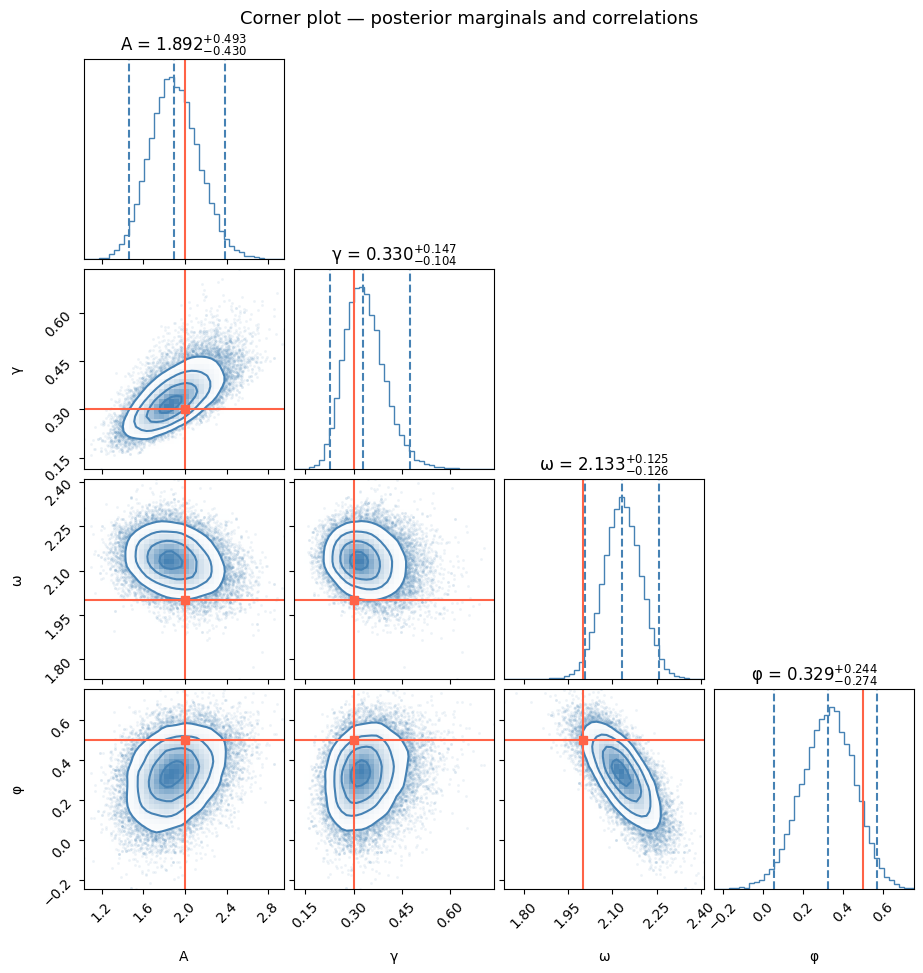

In [9]:
# ── 5. Corner plot — parameter correlations ───────────────────────────────────

fig_corner = corner.corner(
    samples,
    labels=param_names,
    truths=true_values,
    truth_color="tomato",
    color="steelblue",
    bins=40,
    smooth=1.0,
    title_fmt=".3f",
    show_titles=True,
    quantiles=[0.025, 0.5, 0.975],
)
fig_corner.suptitle("Corner plot — posterior marginals and correlations", y=1.01, fontsize=13)
plt.show()

## Upgrading to NUTS

The adaptive Metropolis sampler above works well on this 4-parameter problem, but it has a fundamental limitation: **proposals are isotropic random walks**. Each step is blind to the geometry of the posterior — it does not know which directions are steep or shallow, correlated or independent. Adaptive MH partially compensates by learning the empirical covariance of the chain, but it still takes many small, diffusive steps to traverse the posterior.

### Hamiltonian Monte Carlo (HMC)

HMC borrows an idea from classical mechanics. Augment the parameter vector $\theta$ with a fictitious momentum variable $p$ of the same dimension, and define a Hamiltonian:

$$H(\theta, p) = U(\theta) + K(p), \qquad U(\theta) = -\log \pi(\theta \mid y), \qquad K(p) = \tfrac{1}{2} p^T M^{-1} p$$

where $U$ is the *potential energy* (negative log-posterior) and $K$ is the *kinetic energy* ($M$ is a mass matrix, usually diagonal or the identity). The joint distribution $\exp(-H)$ has $\theta$-marginal equal to the target posterior.

Hamilton's equations of motion are:

$$\dot{\theta} = \frac{\partial H}{\partial p} = M^{-1}p, \qquad \dot{p} = -\frac{\partial H}{\partial \theta} = \nabla_\theta \log \pi(\theta \mid y)$$

Numerically integrating these equations (via the leapfrog integrator) produces a *proposed* $(\theta^*, p^*)$ that has moved a long distance through parameter space while staying near a level set of $H$. Because $H$ is almost exactly conserved along the trajectory, the Metropolis acceptance probability is very close to 1 — proposals are rarely rejected.

The key requirement: **$\log \pi(\theta \mid y)$ must be differentiable** so that $\nabla_\theta \log \pi$ can be evaluated. For this model that is trivially satisfied — the log-posterior is a smooth function of $(A, \gamma, \omega, \phi)$.

#### Leapfrog integration

One leapfrog step with step size $\varepsilon$:

$$p_{t+\varepsilon/2} = p_t + \tfrac{\varepsilon}{2}\,\nabla_\theta \log \pi(\theta_t)$$
$$\theta_{t+\varepsilon} = \theta_t + \varepsilon\, M^{-1} p_{t+\varepsilon/2}$$
$$p_{t+\varepsilon} = p_{t+\varepsilon/2} + \tfrac{\varepsilon}{2}\,\nabla_\theta \log \pi(\theta_{t+\varepsilon})$$

A trajectory of $L$ leapfrog steps costs $L$ gradient evaluations. Choosing $L$ and $\varepsilon$ well is critical: too small and HMC degenerates to a random walk; too large and the trajectory doubles back on itself (U-turn).

### No-U-Turn Sampler (NUTS)

NUTS (Hoffman & Gelman, 2014) eliminates the need to choose $L$ manually. It builds a binary tree of leapfrog steps — doubling the trajectory in either the forward or backward time direction — and **stops when the trajectory makes a U-turn**:

$$(\theta^+ - \theta^-) \cdot p^+ < 0 \quad \text{or} \quad (\theta^+ - \theta^-) \cdot p^- < 0$$

where $\theta^+, p^+$ are the forward endpoint and $\theta^-, p^-$ are the backward endpoint of the current tree. This condition detects when further integration would start retracing already-explored regions. The sampler then draws the next sample uniformly from the valid states on the completed trajectory (slice sampling within the tree).

A dual-averaging scheme (analogous to Robbins-Monro stochastic approximation) automatically tunes $\varepsilon$ during warmup to hit a target acceptance probability (typically 0.8–0.9).

The result: NUTS adapts both step size *and* trajectory length automatically, and typically requires orders of magnitude fewer samples than MH to achieve the same effective sample size.

### Why this model benefits from NUTS

The $\omega$–$\phi$ posterior has a curved ridge: `ω·t + φ` means that increasing $\omega$ while decreasing $\phi$ can produce similar observations, especially at early times. Adaptive MH learns this correlation but still takes small diffusive steps along the ridge. NUTS will integrate along it in a single trajectory.

### Implementation changes

Switching from NumPy MH to NumPyro NUTS requires three things:

1. **JAX backend** — the model function and log-posterior must be written in JAX so that `jax.grad` can compute $\nabla_\theta \log \pi$ automatically.
2. **Differentiable priors** — the hard `if`-bound uniform prior is not differentiable. Replace with NumPyro `dist.Uniform` (which applies the bounds as a log-probability contribution) or with unconstrained transforms (e.g. `dist.HalfNormal` for positive parameters).
3. **NumPyro model function** — declare parameters with `numpyro.sample`, compute the likelihood with `numpyro.sample(..., obs=...)`. NumPyro handles the rest: gradient computation, leapfrog integration, tree building, dual-averaging warmup, and multi-chain execution.

In [10]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"   # Metal does not support NUTS tree ops

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import arviz as az

In [11]:
# ── 6. NumPyro model ──────────────────────────────────────────────────────────
#
# Priors mirror the uniform bounds from log_prior() above, expressed as
# NumPyro distributions so NUTS can differentiate through them.

def damped_spring_model(t, y_obs=None):
    A     = numpyro.sample("A",     dist.Uniform(0.1, 10.0))
    gamma = numpyro.sample("gamma", dist.Uniform(0.01, 2.0))
    omega = numpyro.sample("omega", dist.Uniform(0.1, 10.0))
    phi   = numpyro.sample("phi",   dist.Uniform(-jnp.pi, jnp.pi))

    y_pred = A * jnp.exp(-gamma * t) * jnp.cos(omega * t + phi)

    numpyro.sample("obs", dist.Normal(y_pred, SIGMA_NOISE), obs=y_obs)

In [12]:
# ── 7. Run NUTS ───────────────────────────────────────────────────────────────

t_jax = jnp.array(t_obs)
y_jax = jnp.array(y_obs)

kernel = NUTS(damped_spring_model, target_accept_prob=0.9)
mcmc   = MCMC(kernel, num_warmup=1_000, num_samples=3_000, num_chains=4,
              chain_method="sequential", progress_bar=True)

mcmc.run(jax.random.PRNGKey(0), t=t_jax, y_obs=y_jax)
mcmc.print_summary()

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1776551720.613635 33073852 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1776551720.627111 33073852 service.cc:145] XLA service 0x16843e840 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776551720.627141 33073852 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1776551720.628960 33073852 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1776551720.628983 33073852 mps_client.cc:384] XLA backend will use up to 30150197248 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M3 Pro

systemMemory: 36.00 GB
maxCacheSize: 14.04 GB



sample: 100%|██████████| 4000/4000 [00:00<00:00, 6950.51it/s, 7 steps of size 4.23e-01. acc. prob=0.92]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         A      1.89      0.23      1.88      1.51      2.27   6175.21      1.00
     gamma      0.33      0.06      0.33      0.23      0.43   6366.76      1.00
     omega      2.13      0.06      2.13      2.03      2.23   5688.25      1.00
       phi      0.32      0.13      0.33      0.10      0.53   5378.73      1.00

Number of divergences: 0


In [13]:
# ── 8. Diagnostics — R-hat and ESS ───────────────────────────────────────────
#
# ArviZ converts the NumPyro trace into a standard InferenceData object,
# giving us R-hat (convergence) and ESS (effective sample size) for free.
# R-hat < 1.01 and ESS% > 30% are the targets.

idata = az.from_numpyro(mcmc)

nuts_samples = {k: v for k, v in mcmc.get_samples().items()}
total_draws  = 4 * 3_000

print(f"{'Param':<8} {'True':>8} {'Mean':>8} {'Std':>8} {'2.5%':>8} {'97.5%':>8} {'R-hat':>8} {'ESS%':>8}")
for name, true in zip(["A", "gamma", "omega", "phi"], list(TRUE_PARAMS.values())):
    s      = np.array(nuts_samples[name])
    rhat   = float(az.rhat(idata)[name].values)
    ess    = float(az.ess(idata)[name].values)
    print(f"{name:<8} {true:>8.3f} {s.mean():>8.3f} {s.std():>8.3f} "
          f"{np.percentile(s, 2.5):>8.3f} {np.percentile(s, 97.5):>8.3f} "
          f"{rhat:>8.3f} {100*ess/total_draws:>7.1f}%")

Param        True     Mean      Std     2.5%    97.5%    R-hat     ESS%
A           2.000    1.891    0.233    1.454    2.380    1.001    51.4%
gamma       0.300    0.333    0.062    0.223    0.469    1.001    53.4%
omega       2.000    2.134    0.062    2.014    2.255    1.001    47.5%
phi         0.500    0.324    0.132    0.055    0.569    1.000    44.9%


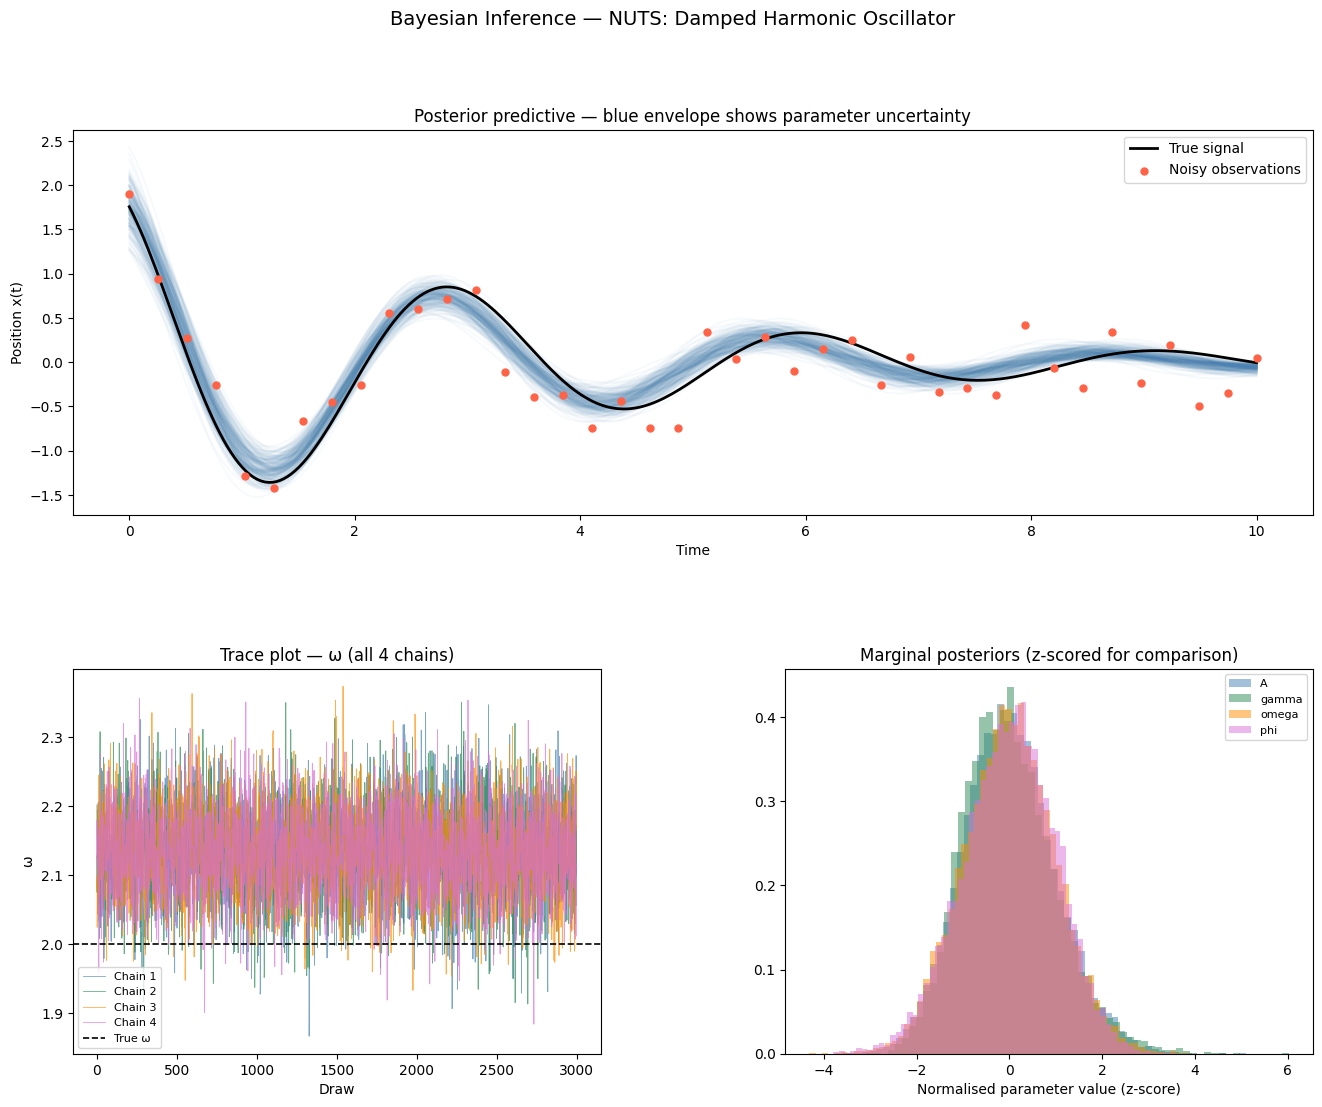

In [14]:
# ── 9. Plots: posterior predictive, trace, marginal histograms ────────────────

all_samples = np.stack([nuts_samples[k] for k in ["A", "gamma", "omega", "phi"]], axis=-1)

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Bayesian Inference — NUTS: Damped Harmonic Oscillator", fontsize=14, y=0.98)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── 9a. Posterior predictive ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
idx = np.random.choice(len(all_samples), 200, replace=False)
for A, gamma, omega, phi in all_samples[idx]:
    ax1.plot(t_fine, model(t_fine, A, gamma, omega, phi), color="steelblue", alpha=0.04)
ax1.plot(t_fine, model(t_fine, **TRUE_PARAMS), "k-", lw=2, label="True signal")
ax1.scatter(t_obs, y_obs, color="tomato", s=25, zorder=5, label="Noisy observations")
ax1.set_xlabel("Time")
ax1.set_ylabel("Position x(t)")
ax1.set_title("Posterior predictive — blue envelope shows parameter uncertainty")
ax1.legend()

# ── 9b. Trace plots (all 4 chains) ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
chain_samples = mcmc.get_samples(group_by_chain=True)
colours_chains = ["steelblue", "seagreen", "darkorange", "orchid"]
for chain_idx, colour in enumerate(colours_chains):
    chain_vals = np.array(chain_samples["omega"][chain_idx])
    ax2.plot(chain_vals, alpha=0.7, lw=0.6, color=colour, label=f"Chain {chain_idx+1}")
ax2.axhline(TRUE_PARAMS["omega"], color="k", linestyle="--", lw=1.2, label="True ω")
ax2.set_xlabel("Draw")
ax2.set_ylabel("ω")
ax2.set_title("Trace plot — ω (all 4 chains)")
ax2.legend(fontsize=8)

# ── 9c. Marginal posteriors ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
colours_params = ["steelblue", "seagreen", "darkorange", "orchid"]
for name, true, colour in zip(["A", "gamma", "omega", "phi"],
                               list(TRUE_PARAMS.values()), colours_params):
    s = np.array(nuts_samples[name])
    normed = (s - s.mean()) / s.std()
    ax3.hist(normed, bins=60, density=True, alpha=0.5, color=colour, label=name)
ax3.set_xlabel("Normalised parameter value (z-score)")
ax3.set_title("Marginal posteriors (z-scored for comparison)")
ax3.legend(fontsize=8)

plt.show()

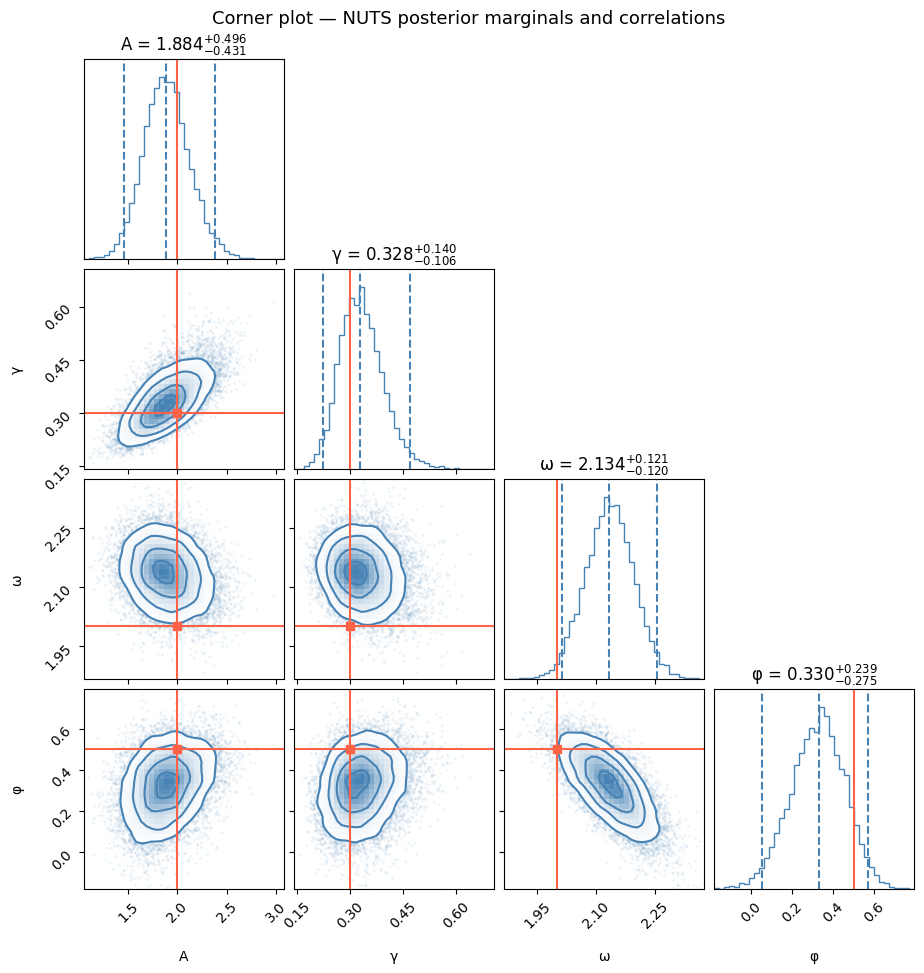

In [15]:
# ── 10. Corner plot ───────────────────────────────────────────────────────────

fig_corner = corner.corner(
    all_samples,
    labels=param_names,
    truths=true_values,
    truth_color="tomato",
    color="steelblue",
    bins=40,
    smooth=1.0,
    title_fmt=".3f",
    show_titles=True,
    quantiles=[0.025, 0.5, 0.975],
)
fig_corner.suptitle("Corner plot — NUTS posterior marginals and correlations", y=1.01, fontsize=13)
plt.show()